### Step 1. 인물모드 직접 해보기

In [1]:
!pip install opencv-python pixellib

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


고양이 이미지 읽기 성공: True
배경 이미지 읽기 성공: True
원본 고양이 이미지 크기: (1086, 1448, 3)
배경(사막) 이미지 크기: (1086, 1448, 3)


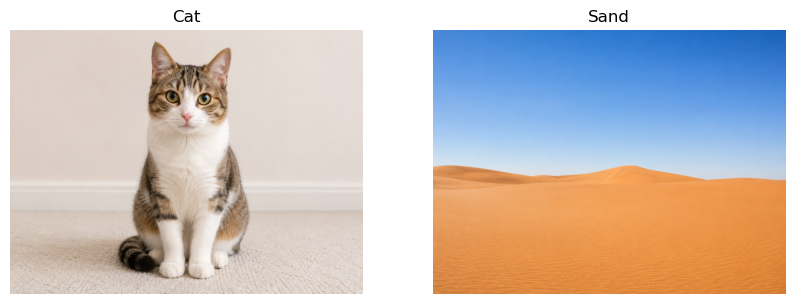

In [3]:
cat_img_path = "cat_img.png"      # 고양이 이미지
sand_img_path = "send_img.png"    # 사막 배경 이미지

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

print("고양이 이미지 읽기 성공:", cat_img is not None)
print("배경 이미지 읽기 성공:", sand_img is not None)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cat_img)
plt.axis("off")
plt.title("Cat")

plt.subplot(1, 2, 2)
plt.imshow(sand_img)
plt.axis("off")
plt.title("Sand")

plt.show()

In [4]:
#기존코드 model = deeplabv3_resnet101(pretrained=True).eval() 
#변경코드

from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights

weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [5]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1086, 1448)


In [6]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


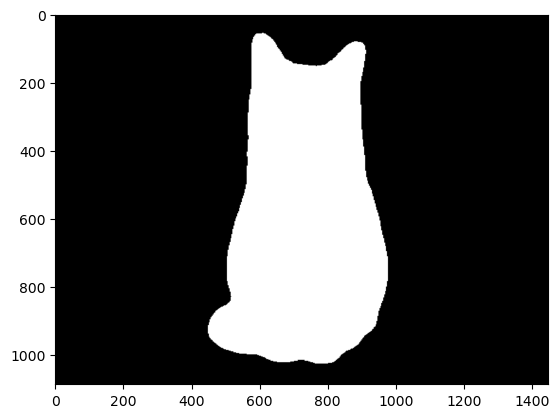

In [7]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

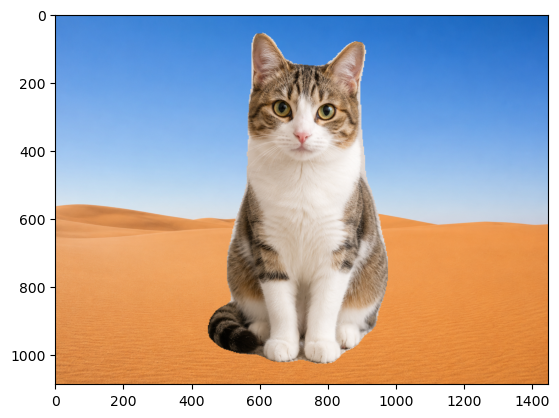

In [8]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

### Step 1-1. 동물 사진 아웃포커싱 (인물모드와 동일한 방식 적용)위에서는 고양이 영역을 추출해 다른 배경(사막)으로 합성하는 배경전환(크로마키) 결과를 만들었다.이번에는 동일한 mask를 이용해, 인물모드와 동일하게 '배경만 blur 처리'하는 아웃포커싱 효과를 고양이 사진에도 적용해본다.이렇게 하면 (1) 인물모드 아웃포커싱 사진, (2) 동물 사진(아웃포커싱), (3) 배경전환 크로마키 사진을 각각 별도로 확인할 수 있다.

In [ ]:
# 고양이 사진에도 인물모드와 동일한 방식(배경 blur)을 적용하여# '동물 사진' 아웃포커싱 결과를 별도로 만든다.# 고양이 원본 사진 자체의 배경을 blur 처리 (사막 합성과는 다른, 원본 배경 기준)cat_blur_bg = cv2.GaussianBlur(cat_img, (21, 21), 0)# img_mask(0/255)를 0/1 마스크로 변환 후 3채널로 확장cat_mask_bin = (img_mask > 0).astype(np.uint8)cat_mask_3ch = np.stack([cat_mask_bin] * 3, axis=-1)# 고양이 영역은 원본 그대로, 배경만 blur 적용animal_portrait_img = np.where(cat_mask_3ch == 1, cat_img, cat_blur_bg)plt.figure(figsize=(8, 8))plt.imshow(animal_portrait_img)plt.axis("off")plt.title("Animal Portrait Mode (Out-focusing)")plt.show()

### Step 2. 사진에서 문제점 찾기

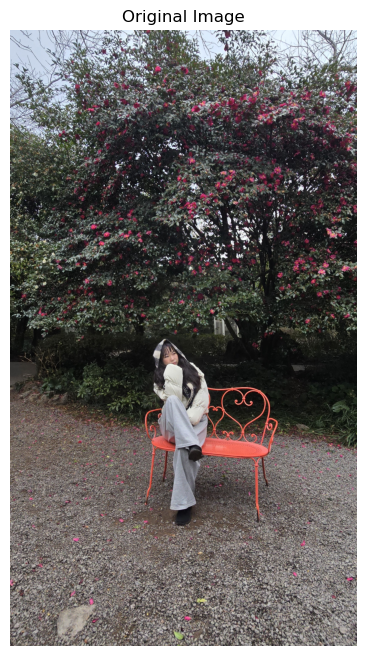

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights

img_path = "person.jpg"  # 본인 이미지 파일명으로 변경

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [10]:
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor()
])

input_tensor = transform(img_rgb).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print("Segmentation mask shape:", output_predictions.shape)

Segmentation mask shape: (520, 520)


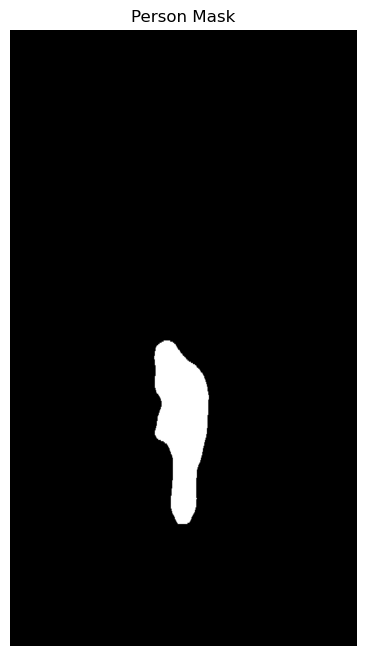

In [11]:
person_mask = (output_predictions == 15).astype(np.uint8)

person_mask = cv2.resize(
    person_mask,
    (img_rgb.shape[1], img_rgb.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

plt.figure(figsize=(8, 8))
plt.imshow(person_mask, cmap="gray")
plt.axis("off")
plt.title("Person Mask")
plt.show()

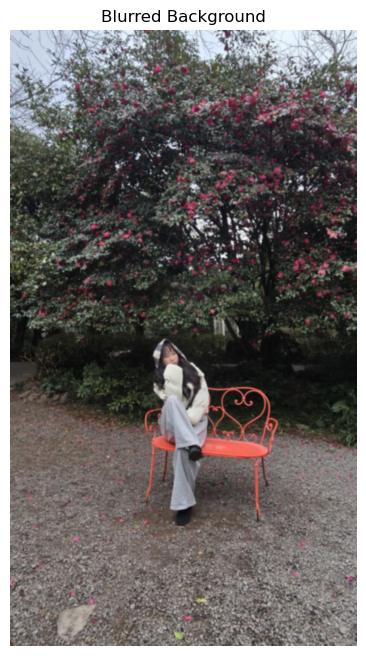

In [12]:
blur_img = cv2.GaussianBlur(img_rgb, (21, 21), 0)

plt.figure(figsize=(8, 8))
plt.imshow(blur_img)
plt.axis("off")
plt.title("Blurred Background")
plt.show()

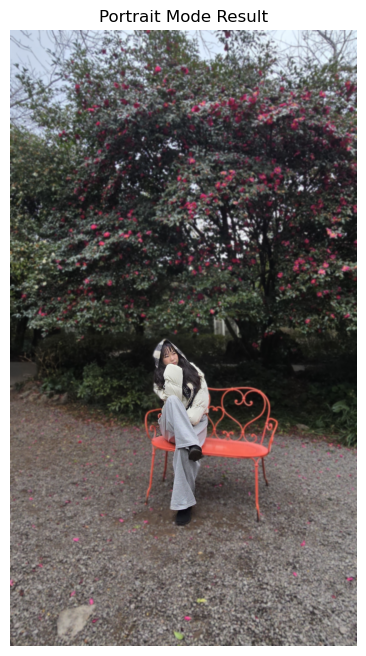

In [13]:
person_mask_3ch = np.stack([person_mask]*3, axis=-1)

portrait_img = np.where(person_mask_3ch == 1, img_rgb, blur_img)

plt.figure(figsize=(8, 8))
plt.imshow(portrait_img)
plt.axis("off")
plt.title("Portrait Mode Result")
plt.show()

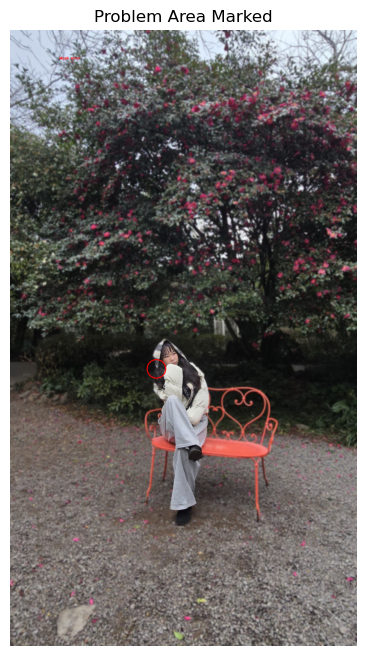

In [14]:
problem_img = portrait_img.copy()

# 예시 좌표: 문제 있는 위치에 맞게 수정
cv2.circle(problem_img, (950, 2200), 60
        , (255, 0, 0), 5)
cv2.putText(problem_img, "Mask error", (320, 190),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(problem_img)
plt.axis("off")
plt.title("Problem Area Marked")
plt.show()

## 문제점 분석

DeepLab 모델을 사용해 인물 영역을 분리하고 배경 blur를 적용하였다. 그러나 결과 이미지에서 segmentation mask가 완벽하지 않아 일부 문제점이 발생하였다.

첫째, 사람과 배경의 경계가 부자연스럽게 보일 수 있다. 특히 머리카락, 옷의 가장자리, 손 주변처럼 경계가 복잡한 부분은 mask가 정확하게 분리하지 못할 수 있다.

둘째, 실제로는 배경에 해당하는 부분이 사람 영역으로 잘못 포함되면 해당 영역이 blur 처리되지 않고 선명하게 남을 수 있다.

셋째, 반대로 사람의 일부가 배경으로 잘못 분류되면 인물의 일부가 흐려져 어색한 결과가 나타날 수 있다.

이러한 문제는 Semantic Segmentation 모델이 이미지의 각 픽셀을 완벽하게 분류하지 못하기 때문에 발생한다.



### 좌표수정 
기존 위치(300,200),40  
엉뚱한곳에 빨간원 표시가 나타나서 , 위치수정  
(950, 2200), 60  


## 해결 방안 제안

현재 결과에서 발생한 문제의 주요 원인은 DeepLab 모델이 생성한 semantic segmentation mask의 부정확성이다. 따라서 모델이 만든 mask를 그대로 사용하기보다, 후처리를 적용하여 보정할 필요가 있다.

첫 번째 방법은 morphological operation을 사용하는 것이다. Opening 연산을 적용하면 배경에 잘못 포함된 작은 노이즈를 제거할 수 있고, Closing 연산을 적용하면 인물 영역 내부의 작은 빈틈을 메울 수 있다. 또한 Dilation을 적용하면 머리카락이나 손처럼 누락되기 쉬운 인물 가장자리 영역을 조금 더 포함시킬 수 있다.

두 번째 방법은 mask 자체에 Gaussian Blur를 적용하는 것이다. 현재 방식은 사람 영역과 배경 영역이 mask 기준으로 딱 잘려 합성되기 때문에 경계가 부자연스럽게 보일 수 있다. mask를 부드럽게 만든 뒤 alpha 값처럼 사용하면 원본 인물 이미지와 blur 배경 이미지가 자연스럽게 섞여 경계가 덜 어색해진다.

세 번째 방법은 depth estimation을 함께 활용하는 것이다. Semantic Segmentation은 사람과 배경을 구분할 수는 있지만, 배경이 카메라에서 얼마나 떨어져 있는지는 알 수 없다. Depth Estimation을 사용하면 각 픽셀의 거리 정보를 추정할 수 있고, 이를 바탕으로 가까운 배경은 약하게 blur 처리하고 먼 배경은 더 강하게 blur 처리할 수 있다. 이렇게 하면 실제 카메라의 얕은 피사계 심도 효과에 더 가까운 결과를 만들 수 있다.

따라서 본 프로젝트에서는 우선적으로 mask 후처리를 적용하는 방법이 가장 현실적인 개선 방향이라고 판단하였다. DeepLab이 만든 mask에 opening, closing, dilation, Gaussian Blur를 적용하면 mask 오류를 줄이고 인물과 배경의 경계를 더 자연스럽게 만들 수 있다.


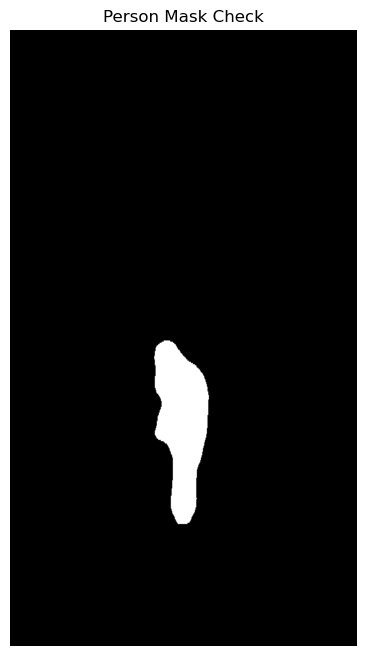

In [17]:
plt.figure(figsize=(8, 8))
plt.imshow(person_mask, cmap="gray")
plt.axis("off")
plt.title("Person Mask Check")
plt.show()

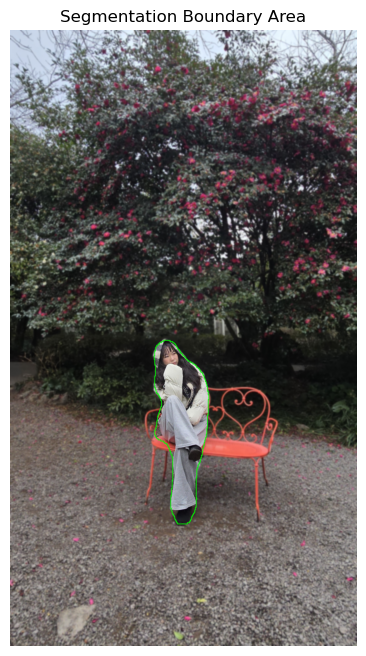

In [18]:
# person_mask: 사람 영역 1, 배경 0
# portrait_img: 인물모드 결과 이미지

mask_uint8 = (person_mask * 255).astype(np.uint8)

# 경계선 찾기
edges = cv2.Canny(mask_uint8, 50, 150)

# 경계선을 두껍게 만들기
kernel = np.ones((5, 5), np.uint8)
edges_thick = cv2.dilate(edges, kernel, iterations=1)

# 결과 이미지 복사
boundary_img = portrait_img.copy()

# 경계선을 밝은 초록색으로 표시
boundary_img[edges_thick > 0] = [0, 255, 0]

plt.figure(figsize=(8, 8))
plt.imshow(boundary_img)
plt.axis("off")
plt.title("Segmentation Boundary Area")
plt.show()

### 문제점 추가 확인## 경계 영역 시각화를 통한 보충 설명앞서 16번 셀(문제점 분석)에서는 머리카락, 어깨, 옷 가장자리처럼 경계가 복잡한 부분에서 mask 오류가 발생할 수 있다고 분석하였다.이를 더 명확히 보여주기 위해, segmentation mask의 경계선 자체를 시각화하여 인물과 배경이 나뉘는 영역을 다시 확인하였다.초록색으로 표시된 부분이 바로 16번 셀에서 설명한, mask가 불안정해지기 쉬운 경계 영역이다.이번 사진에서는 해당 경계가 비교적 자연스럽게 처리되어 눈에 띄는 큰 오류로는 이어지지 않았지만,배경이 복잡하거나 인물과 배경의 색이 비슷한 경우에는 이 경계 영역에서 오분류가 발생할 가능성이 높다.즉, 16번 셀의 분석 결과(경계 부근 오류 가능성)와 이번 시각화 결과는 같은 문제를 두 가지 방식(직접 지적 / 경계 시각화)으로 보여주는 보완적인 설명이다.